<a href="https://colab.research.google.com/github/abhaysenthilkumar369-web/cusat-internship/blob/main/ABHAY_S_Curve_Fitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

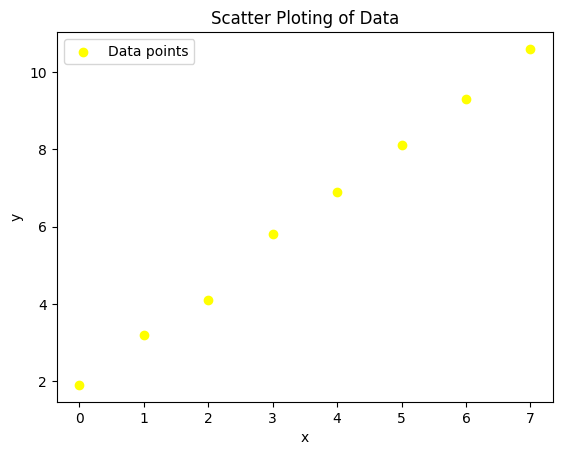

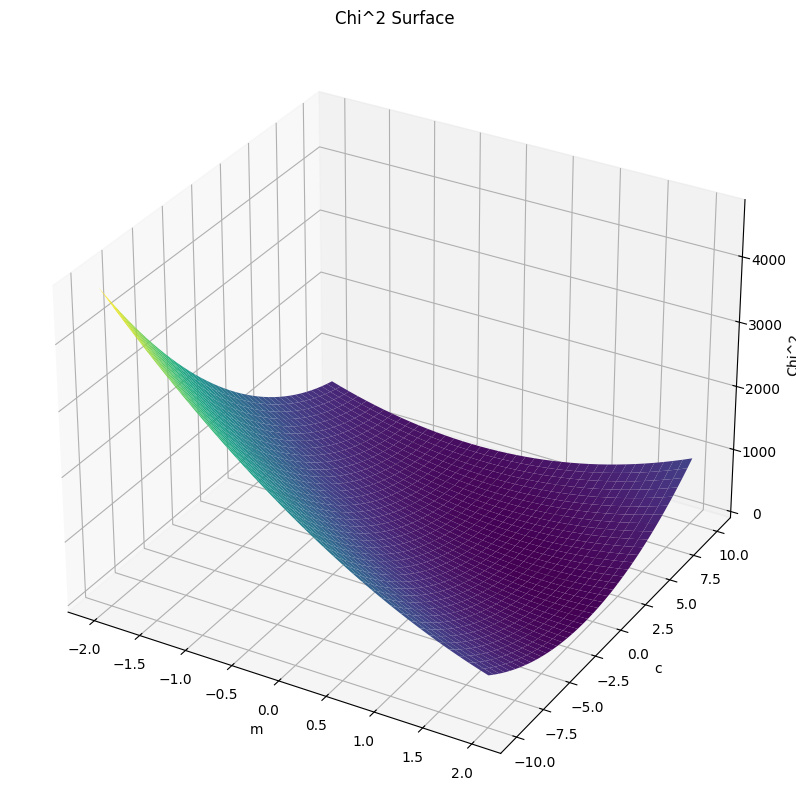

Brute-force best fit: m = 1.2000000000000028 , c = 1.9999999999999574


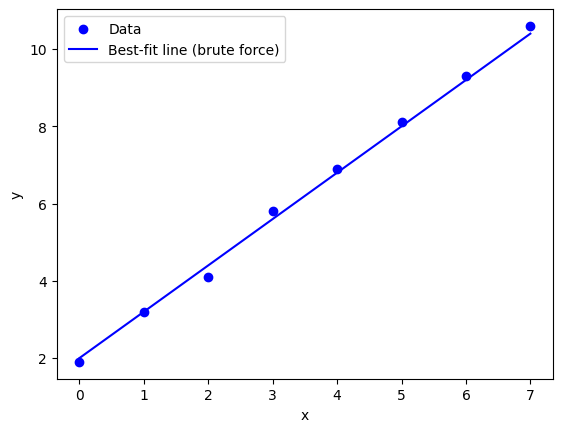

Polyfit best fit: m = 1.2440476190476188 , c = 1.883333333333333


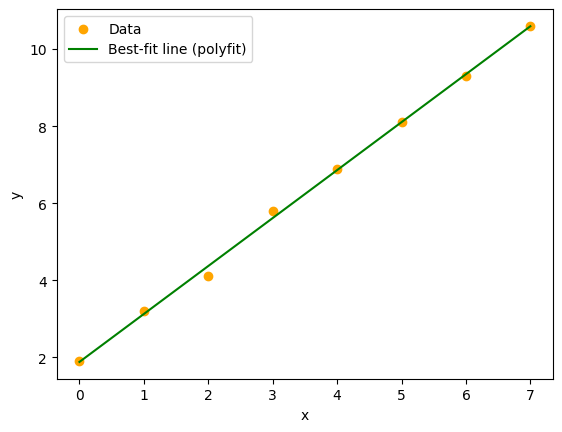

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0,1,2,3,4,5,6,7])
y = np.array([1.9,3.2,4.1,5.8,6.9,8.1,9.3,10.6])

# Scattering plot of the data
plt.scatter(x, y, color='yellow', label='Data points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Ploting of Data')
plt.legend(loc='upper left')
plt.show()

# gird search calculation of X**2
m_values = np.arange(-2, 2.1, 0.1)
c_values = np.arange(-10, 10.1, 0.1)
chi2 = np.zeros((len(m_values), len(c_values)))
for i, m in enumerate(m_values):
    for j, c in enumerate(c_values):
        y_model = m*x + c                 # y=m*x+c slop in linear eqn
        chi2[i,j] = np.sum((y - y_model)**2)

# 3D ploting of X**2 (m,c)
M, C = np.meshgrid(m_values, c_values)
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(M, C, chi2.T, cmap='viridis')
ax.set_xlabel('m')
ax.set_ylabel('c')
ax.set_zlabel('Chi^2')
plt.title('Chi^2 Surface')
plt.show()

# best-fit parameters from the b-force
min_index = np.unravel_index(np.argmin(chi2), chi2.shape)
m_best = m_values[min_index[0]]
c_best = c_values[min_index[1]]
print("Brute-force best fit: m =", m_best, ", c =", c_best)

# Plot best-fit line
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, m_best*x + c_best, color='blue', label='Best-fit line (brute force)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.show()

# Fit using numpy.polyfit
m_poly, c_poly = np.polyfit(x, y, 1)
print("Polyfit best fit: m =", m_poly, ", c =", c_poly)

# Plot polyfit line
plt.scatter(x, y, color='orange', label='Data')
plt.plot(x, m_poly*x + c_poly, color='green', label='Best-fit line (polyfit)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.show()

# all the 4 graph's savefig as png format in the file
plt.savefig('scatter_plot.png')
plt.savefig('chi2_surface.png')
plt.savefig('brute_force_line.png')
plt.savefig('polyfit_line.png')

In [2]:
from mpl_toolkits.mplot3d import Axes3D
